Starting Multi-Agent Simulation (3 Predators vs 1 Prey)...
Monitor uses Mixture Martingale over grid: [0.1, 0.3, 0.5, 0.7, 0.9]
True Eps   | Avg Tau   
------------------------------
0.05       | 2413.6    
0.10       | 636.7     
0.20       | 156.4     
0.30       | 66.6      
0.40       | 41.8      
0.60       | 16.7      
0.80       | 9.8       


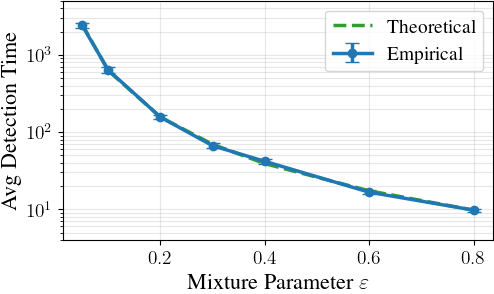

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tueplots import bundles

# configuration and game settings
grid_size = 10
num_predators = 3 # total predators (1 suspect + N-1 honest)
actions = [0, 1, 2, 3, 4] # stay, up, down, left, right
action_names = ["Stay", "Up", "Down", "Left", "Right"]
threshold = 20.0 # threshold for rejection
trials_per_epsilon = 100 # number of Monte Carlo runs per epsilon
max_steps = 5000 # safety cutoff

# true epsilons (what the cheater actually uses)
true_epsilons = [0.05, 0.1, 0.2, 0.3, 0.4, 0.6, 0.8]

# monitor's hypothesis grid (the mixture)
mixture_grid = [0.1, 0.3, 0.5, 0.7, 0.9]

np.random.seed(0)

# game dynamics

def get_next_pos(pos, action):
    """calculates next position given 5x5 grid with boundaries"""
    row, col = pos
    if action == 0:   # stay
        return (row, col)
    elif action == 1: # up
        return (max(0, row - 1), col)
    elif action == 2: # down
        return (min(grid_size - 1, row + 1), col)
    elif action == 3: # left
        return (row, max(0, col - 1))
    elif action == 4: # right
        return (row, min(grid_size - 1, col + 1))
    return pos

def dist_sq(pos1, pos2):
    return (pos1[0] - pos2[0])**2 + (pos1[1] - pos2[1])**2

# strategies

def get_null_probs():
    """H0: uniform random walk (1/5 prob for each action)"""
    return np.ones(5) / 5.0

def get_optimal_probs(pred_pos, prey_pos):
    """
    H1: heuristic strategy; assigns higher probability to moves that reduce distance to prey"""
    probs = np.zeros(5)
    current_dist = dist_sq(pred_pos, prey_pos)

    # evaluate all moves
    for act in actions:
        next_p = get_next_pos(pred_pos, act)
        new_d = dist_sq(next_p, prey_pos)
        
        if new_d < current_dist:
            probs[act] = 10.0 # strong preference
        elif new_d == current_dist:
            probs[act] = 1.0  # neutral
        else:
            probs[act] = 0.1  # avoid moving away
            
    return probs / np.sum(probs)

def get_mixture_probs(pred_pos, prey_pos, epsilon):
    """observed strategy: (1 - eps) * Null + eps * Optimal"""
    p_null = get_null_probs()
    p_opt = get_optimal_probs(pred_pos, prey_pos)
    return (1 - epsilon) * p_null + epsilon * p_opt

# simulation loop

results_tau = []
results_std = []

print(f"Starting Multi-Agent Simulation ({num_predators} Predators vs 1 Prey)...")
print(f"Monitor uses Mixture Martingale over grid: {mixture_grid}")
print(f"{'True Eps':<10} | {'Avg Tau':<10}")
print("-" * 30)

for true_epsilon in true_epsilons:
    taus = []
    
    for _ in range(trials_per_epsilon):
        # reset Game
        predators = [(0, 0) for _ in range(num_predators)]
        prey_pos = (grid_size-1, grid_size-1) 
        # initialize K martingales
        candidate_martingales = np.ones(len(mixture_grid))
        
        t = 0
        detected = False
        
        while not detected and t < max_steps:
            t += 1
            
            # 1. predator moves
            next_predators = []
            catch_event = False
            
            for i in range(num_predators):
                current_pos = predators[i]
                
                if i == 0: 
                    # the suspect agent plays using the TRUE epsilon
                    p_null = get_null_probs()
                    p_true = get_mixture_probs(current_pos, prey_pos, true_epsilon)
                    # sample Action
                    action = np.random.choice(actions, p=p_true)
                    
                    # the monitor does not know 'true_epsilon'. 
                    for k, candidate_eps in enumerate(mixture_grid):
                        # what would the prob be if the agent was using candidate_eps?
                        p_hyp = get_mixture_probs(current_pos, prey_pos, candidate_eps)
                        # update component martingale
                        lr = p_hyp[action] / p_null[action]
                        candidate_martingales[k] *= lr
                    
                    # the test statistic is the average (uniform mixture)
                    mixture_martingale_value = np.mean(candidate_martingales)
                    
                    if mixture_martingale_value >= threshold:
                        detected = True
                    
                else:
                    # honest agents
                    p_null = get_null_probs()
                    action = np.random.choice(actions, p=p_null)
                
                # execute move
                new_pos = get_next_pos(current_pos, action)
                next_predators.append(new_pos)
                
                if new_pos == prey_pos:
                    catch_event = True
            
            predators = next_predators

            # 2. prey move
            prey_action = np.random.choice(actions) 
            prey_pos = get_next_pos(prey_pos, prey_action)
            
            if any(p == prey_pos for p in predators):
                catch_event = True
            
            # 3. reset if caught
            if catch_event:
                predators = [(0, 0) for _ in range(num_predators)]
                prey_pos = (grid_size-1, grid_size-1)

        taus.append(t)

    avg_tau = np.mean(taus)
    results_tau.append(avg_tau)
    results_std.append(np.std(taus) / np.sqrt(trials_per_epsilon)) 
    
    print(f"{true_epsilon:<10.2f} | {avg_tau:<10.1f}")

# plotting

# style setup
plt.rcParams.update(bundles.icml2024())
plt.rcParams.update({
    "axes.labelsize": 16,
    "axes.titlesize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "lines.linewidth": 2.5,
})

# theoretical scaling: T ~ K / epsilon^2
# anchor to the last point (largest epsilon)
anchor_idx = -1 
last_eps = true_epsilons[anchor_idx]
last_tau = results_tau[anchor_idx]

# calculate constant K
K = last_tau * (last_eps ** 2)

# generate theoretical curve
theoretical_y = [K / (e**2) for e in true_epsilons]

plt.figure(figsize=(5, 3))

# plot empirical data
plt.errorbar(true_epsilons, results_tau, yerr=results_std, fmt='o-', 
             label='Empirical', 
             color='#1f77b4', ecolor='#1f77b4', capsize=5)

# plot theoretical curve
plt.plot(true_epsilons, theoretical_y, linestyle='--', 
         label='Theoretical', 
         color='#2ca02c', linewidth=2.5)

plt.ylim(4,5000)

plt.yscale('log')
plt.xscale('linear')

plt.xlabel(r"Mixture Parameter $\varepsilon$")
plt.ylabel(r"Avg Detection Time")
plt.grid(True, which='both', alpha=0.3)
plt.legend()

save_path = 'plots/predator-prey/scaling.pdf'
plt.savefig(save_path, format="pdf", bbox_inches="tight")

Running visual episode with Epsilon=0.6...
Step  | Suspect Pos     | Action     | Martingale   | Probabilities (Stay, Up, Down, Left, Right)
----------------------------------------------------------------------------------------------------------------------------------
0     | (0, 0)          | Down       | 1.00         | [  0.11,   0.11,   0.34,   0.11,   0.34]
1     | (1, 0)          | Right      | 1.59         | [  0.11,   0.08,   0.35,   0.11,   0.35]
2     | (1, 1)          | Right      | 2.71         | [  0.11,   0.08,   0.36,   0.08,   0.36]
3     | (1, 2)          | Down       | 4.97         | [  0.11,   0.08,   0.36,   0.08,   0.36]
4     | (2, 2)          | Stay       | 9.48         | [  0.11,   0.08,   0.36,   0.08,   0.36]
5     | (2, 2)          | Right      | 4.34         | [  0.11,   0.08,   0.36,   0.08,   0.36]
6     | (2, 3)          | Right      | 8.04         | [  0.11,   0.08,   0.36,   0.08,   0.36]
7     | (2, 4)          | Right      | 15.38        | [  0.11, 

C:\Users\etgauthi\AppData\Local\Temp\ipykernel_38448\3473856450.py:145: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


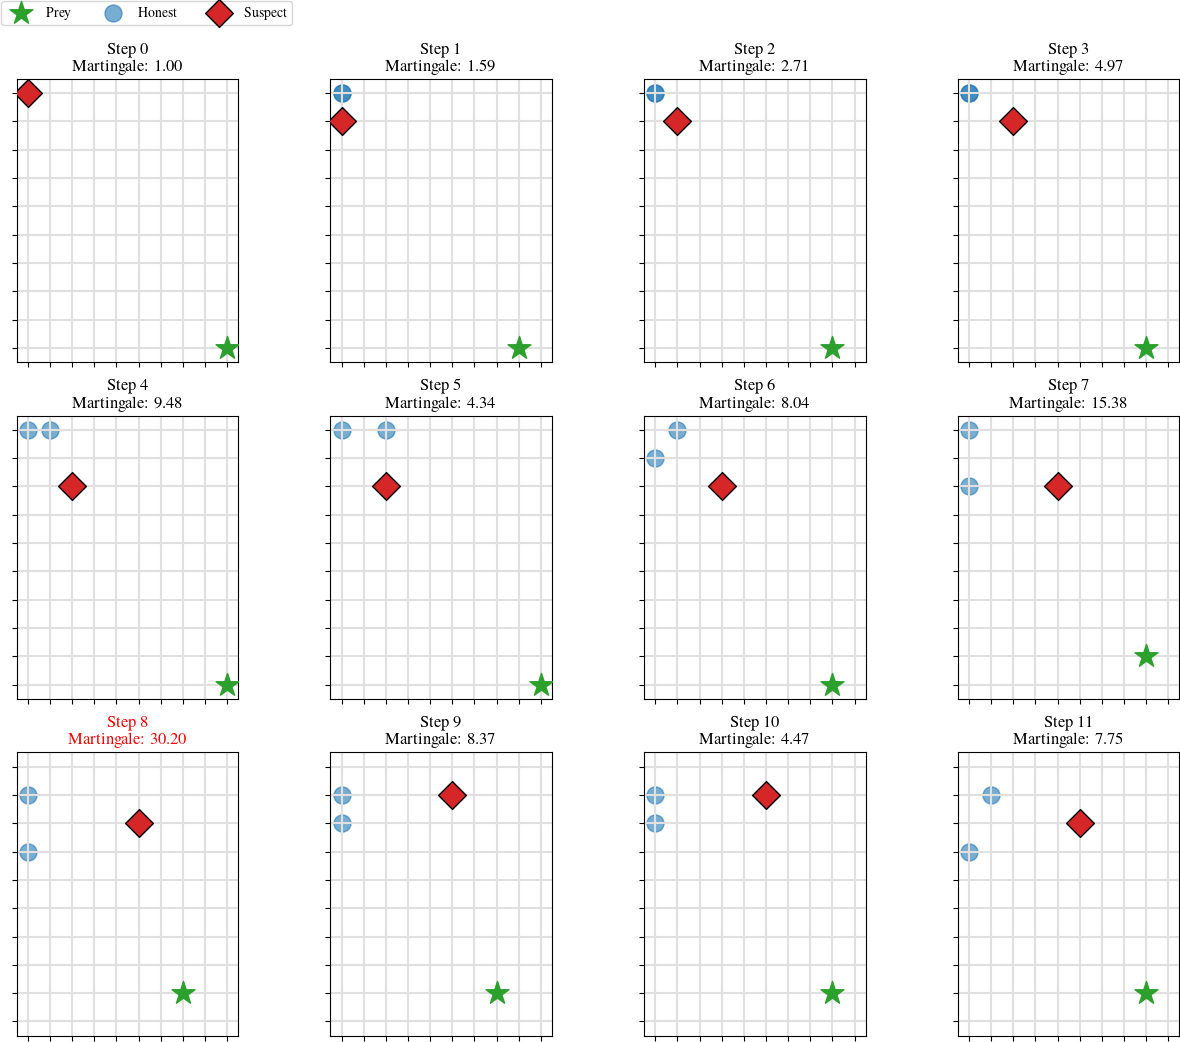

In [ ]:
import csv

# colors for visualization
color_prey = '#2ca02c'    
color_suspect = '#d62728'   
color_honest = '#1f77b4'    
color_grid = '#e0e0e0'

np.random.seed(0)

# visualization

def run_visual_episode(true_epsilon, steps_to_record=25, save_csv_name=None):
    # setup
    predators = [(0, 0) for _ in range(num_predators)]
    prey_pos = (grid_size-1, grid_size-1)
    
    # martingale state
    candidate_martingales = np.ones(len(mixture_grid))
    history = []
    csv_rows = []
    
    print(f"Running visual episode with Epsilon={true_epsilon}...")
    print(f"{'Step':<5} | {'Suspect Pos':<15} | {'Action':<10} | {'Martingale':<12} | {'Probabilities (Stay, Up, Down, Left, Right)'}")
    print("-" * 130)
    
    for t in range(steps_to_record):
        # 1. record State before moves
        current_martingale = np.mean(candidate_martingales)
        history.append({
            'step': t,
            'predators': predators.copy(),
            'prey': prey_pos,
            'martingale': current_martingale,
            'caught': any(p == prey_pos for p in predators)
        })
        
        # 2. agent moves
        next_predators = []
        
        # suspect (index 0)
        suspect_pos = predators[0]
        p_null = get_null_probs()
        p_true = get_mixture_probs(suspect_pos, prey_pos, true_epsilon)
        action_s = np.random.choice(actions, p=p_true)
        
        # logging
        act_name = action_names[action_s]
        prob_str = ", ".join([f"{v:6.2f}" for v in p_true])
        print(f"{t:<5} | {str(suspect_pos):<15} | {act_name:<10} | {current_martingale:<12.2f} | [{prob_str}]")
        
        # collect data for CSV
        if save_csv_name:
            row = [t, suspect_pos[0], suspect_pos[1], act_name, current_martingale] + list(p_true)
            csv_rows.append(row)
        
        # monitor update
        for k, candidate_eps in enumerate(mixture_grid):
            p_hyp = get_mixture_probs(suspect_pos, prey_pos, candidate_eps)
            lr = p_hyp[action_s] / p_null[action_s]
            candidate_martingales[k] *= lr
            
        next_predators.append(get_next_pos(suspect_pos, action_s))
        
        # honest agents
        for i in range(1, num_predators):
            p_honest = get_null_probs()
            act_h = np.random.choice(actions, p=p_honest)
            next_predators.append(get_next_pos(predators[i], act_h))
            
        predators = next_predators
        
        # prey move
        act_prey = np.random.choice(actions)
        prey_pos = get_next_pos(prey_pos, act_prey)
        
        # reset if caught
        if any(p == prey_pos for p in predators):
            predators = [(0, 0) for _ in range(num_predators)]
            prey_pos = (grid_size-1, grid_size-1)
            
    # save CSV
    if save_csv_name:
        csv_path = f'results/{save_csv_name}'
        with open(csv_path, 'w', newline='') as f:
            writer = csv.writer(f)
            header = ['Step', 'Suspect_Row', 'Suspect_Col', 'Action', 'Martingale', 
                      'Prob_Stay', 'Prob_Up', 'Prob_Down', 'Prob_Left', 'Prob_Right']
            writer.writerow(header)
            writer.writerows(csv_rows)   

    return history

# plotting function
def plot_film_strip(history, save_filename):
    n_steps = len(history)
    cols = 4
    rows = (n_steps + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(cols*3, rows*3.5))
    axes_flat = axes.flatten()
    
    for i, state in enumerate(history):
        ax = axes_flat[i]
        
        # grid setup
        ax.set_xlim(-0.5, grid_size-0.5)
        ax.set_ylim(grid_size-0.5, -0.5) # invert Y to match matrix coords
        ax.set_xticks(np.arange(grid_size))
        ax.set_yticks(np.arange(grid_size))
        ax.grid(color=color_grid, linestyle='-', linewidth=1.5)
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        
        # draw prey
        py, px = state['prey']
        ax.scatter(px, py, s=300, marker='*', c=color_prey, label='Prey', zorder=10)
        
        # draw honest predators
        for idx, hp in enumerate(state['predators'][1:]):
            hy, hx = hp
            label = 'Honest' if idx == 0 else None
            ax.scatter(hx, hy, s=150, marker='o', c=color_honest, alpha=0.6, label=label)
            
        # draw suspect predator
        sy, sx = state['predators'][0]
        ax.scatter(sx, sy, s=200, marker='D', c=color_suspect, edgecolors='black', label='Suspect', zorder=11)
        
        # info
        m_val = state['martingale']
        title_color = 'black'
        if m_val > threshold: title_color = 'red'
        
        ax.set_title(f"Step {state['step']}\nMartingale: {m_val:.2f}", 
                     fontsize=12, fontweight='bold', color=title_color)
        
        # add legend only to first plot
        if i == 0:
            ax.legend(loc='upper left', bbox_to_anchor=(-0.1, 1.3), fontsize=10, ncol=3)

    # hide empty subplots
    for j in range(n_steps, len(axes_flat)):
        axes_flat[j].axis('off')
        
    plt.tight_layout()
    plt.savefig(f'plots/{save_filename}', format='pdf', bbox_inches='tight')

# execution

# run a short episode with a distinct cheater (epsilon=0.6)
history_data = run_visual_episode(true_epsilon=0.6, steps_to_record=12, save_csv_name="predator-prey/history.csv")
plot_film_strip(history_data, "predator-prey/gameplay.pdf")
plt.show()